In [1]:
!pip install transformers accelerate bitsandbytes \
             qwen-vl-utils pillow pandas tqdm \
             datasets matplotlib seaborn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 51.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.4

1：公共配置（只跑一次）
  - 挂载 Drive
  - 安装依赖
  - 加载测试集 JSON
  - 定义 ask_vlm() 和 auto_judge() 函数

In [2]:
# ── Cell 1-2：挂载 Google Drive ────────────────────────────────
# 【每次重连必跑】


IMAGE_BASE = "/kaggle/working/vlm-hallucination-images/coco"
RESULTS_BASE = "/kaggle/working/vlm-hallucination-images/results"
DATASET_PATH = "/kaggle/working/results/test_dataset.json"

import os
os.makedirs(RESULTS_BASE, exist_ok=True)
print("✓ Drive 挂载完成")
print(f"  图片目录: {IMAGE_BASE}")
print(f"  结果目录: {RESULTS_BASE}")

✓ Drive 挂载完成
  图片目录: /kaggle/working/vlm-hallucination-images/coco
  结果目录: /kaggle/working/vlm-hallucination-images/results


In [3]:
# ── Cell 1-3：导入所有依赖 ─────────────────────────────────────
# 【每次重连必跑】
import json, re, time
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image


matplotlib.rcParams['axes.unicode_minus'] = False
print("✓ 依赖导入完成")


✓ 依赖导入完成


In [7]:
# ── Cell 1-4：加载测试集 ───────────────────────────────────────
# 【每次重连必跑】
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    DATASET = json.load(f)

print(f"✓ 测试集加载完成，共 {len(DATASET)} 道题")

# 统计各类型分布
from collections import Counter
type_counts = Counter(item["type"] for item in DATASET)
print("题目类型分布：")
for t, c in type_counts.items():
    print(f"  {t}: {c} 道")



✓ 测试集加载完成，共 100 道题
题目类型分布：
  object_existence: 20 道
  count_attr: 20 道
  ocr_text: 20 道
  cultural: 20 道
  lang_priming: 20 道


In [4]:
# ── Cell 1-5：定义推理函数 ask_vlm() ──────────────────────────
# 【每次重连必跑】注意：需要先在对应 Section 加载模型后才能调用

def ask_vlm_qwen(model, processor, image_path, question):
    """Qwen2-VL 推理函数（显存优化版）"""
    from qwen_vl_utils import process_vision_info
    import torch

    # 限制图片最大像素（大幅降低显存）
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path, "max_pixels": 672*672},  # 约0.45M像素
            {"type": "text",  "text": question}
        ]
    }]

    try:
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        image_inputs, _ = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs,
            padding=True, return_tensors="pt"
        ).to("cuda")

        # 🔥 生成配置：短输出 + 禁用 KV cache（省显存）
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=50,        # 足够回答是/否/数量
                do_sample=False,
                use_cache=False,          # 省显存但稍慢
                pad_token_id=processor.tokenizer.pad_token_id
            )
        trimmed = out[0][inputs.input_ids.shape[1]:]
        response = processor.decode(trimmed, skip_special_tokens=True)
        return response

    except Exception as e:
        print(f"⚠️ 推理异常: {type(e).__name__}: {str(e)[:100]}")
        return ""   # 返回空字符串，由 run_experiment 标记为 error

    finally:
        # 🔥 强制释放显存
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        # 删除大变量帮助垃圾回收
        if 'inputs' in locals():
            del inputs
        if 'image_inputs' in locals():
            del image_inputs


def ask_vlm_llava(model, processor, image_path, question):
    """LLaVA 推理函数"""
    from PIL import Image
    import torch

    image = Image.open(image_path).convert("RGB")
    
    # LLaVA-1.6 需要特定的 prompt 格式
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]
        }
    ]
    
    prompt = processor.apply_chat_template(
        conversation, add_generation_prompt=True)
    
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to("cuda")
    
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False
        )
    
    # 只取新生成的部分
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return processor.decode(new_tokens, skip_special_tokens=True)


def ask_vlm_intern(model, tokenizer, image_path, question):
    """InternVL2 推理函数"""
    import torch
    import torchvision.transforms as T
    from torchvision.transforms.functional import InterpolationMode

    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD  = (0.229, 0.224, 0.225)

    def build_transform(input_size=448):
        return T.Compose([
            T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
            T.Resize((input_size, input_size),
                     interpolation=InterpolationMode.BICUBIC),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])

    transform = build_transform()
    image = Image.open(image_path).convert("RGB")
    pixel_values = transform(image).unsqueeze(0).to(torch.float16).cuda()

    generation_config = dict(max_new_tokens=100, do_sample=False)
    response = model.chat(tokenizer, pixel_values,
                          question, generation_config)
    return response

print("✓ 推理函数定义完成")


✓ 推理函数定义完成


In [5]:
import re

def auto_judge(response: str, item: dict) -> str:
    resp = str(response).strip().lower()
    q_type = item.get("type", "")
    gt = str(item.get("ground_truth", "")).strip().lower()

    # lang_priming 单独处理
    if q_type == "lang_priming":
        if re.search(r'\(\d+,\d+\)', resp):
            return "hallucination"
        correction_words = ["没有","不存在","不是","并没有",
                           "不对","只有","而不是","并非","无法回答"]
        if any(w in resp for w in correction_words):
            return "correct"
        return "hallucination"

    # 其他所有类型：纯关键词匹配
    correct_kws = [k.strip().lower() for k in
                   item.get("keywords_correct", [])]
    if not correct_kws:
        return "hallucination"
    if any(k in resp for k in correct_kws):
        return "correct"
    return "hallucination"

In [12]:
# ── Cell 1-7：定义批量实验函数 run_experiment（断点续跑）──
import os
import time
import torch
import pandas as pd
from tqdm import tqdm

def run_experiment(model_name, ask_fn, dataset,
                   lang="zh", delay=0.5, save=True):
    """
    批量跑实验，支持断点续跑（自动跳过已完成的题目）
    model_name : 模型名称字符串，用于命名结果文件
    ask_fn     : lambda image_path, question -> response
    lang       : "zh" 用 question_zh，"en" 用 question_en
    """
    q_key = "question_zh" if lang == "zh" else "question_en"
    
    # 根据 image_path 前缀映射到真实绝对路径
    BASE_MAP = {
        "images/coco/": "/kaggle/input/datasets/stayyang/vlm-hallucination-images/coco_200/coco/",
        "images/ocr/":  "/kaggle/input/datasets/stayyang/vlm-hallucination-images/ocr/ocr/",
        "images/cultural/": "/kaggle/input/datasets/stayyang/vlm-hallucination-images/cultural/cultural/",
    }
    
    save_path = f"{RESULTS_BASE}/results_{model_name}_{lang}.csv"
    
    # ---------- 断点续跑：读取已有结果 ----------
    completed_ids = set()
    if os.path.exists(save_path):
        existing_df = pd.read_csv(save_path)
        completed_ids = set(existing_df["id"].values)
        records = existing_df.to_dict("records")
        print(f"✅ 从已有结果恢复，已完成 {len(records)} 条，待完成 {len(dataset) - len(records)} 条")
    else:
        records = []
        print(f"🆕 新建结果文件，共 {len(dataset)} 道题")
    # -----------------------------------------
    
    for item in tqdm(dataset, desc=f"{model_name} ({lang})"):
        if item["id"] in completed_ids:
            continue   # 跳过已完成的
        
        # 构造图片绝对路径
        img_rel = item["image_path"]
        base = None
        for prefix, path in BASE_MAP.items():
            if img_rel.startswith(prefix):
                base = path
                break
        if base is None:
            raise ValueError(f"未知的图片路径前缀: {img_rel}")
        image_path = base + os.path.basename(img_rel)
        
        question = item[q_key]
        try:
            response = ask_fn(image_path, question)
            judgment = auto_judge(response, item)   # 使用 Cell 1-6 定义的 auto_judge
            error = None
        except Exception as e:
            response = ""
            judgment = "error"
            error = str(e)
        
        records.append({
            "id":               item["id"],
            "type":             item["type"],
            "is_trap":          item.get("is_trap", False),
            "difficulty":       item.get("difficulty", ""),
            "question":         question,
            "ground_truth":     item["ground_truth"],
            "response":         response,
            "judgment":         judgment,
            "is_hallucination": int(judgment == "hallucination"),
            "lang":             lang,
            "model":            model_name,
            "error":            error,
        })
        
        # 每完成 5 题保存一次进度
        if len(records) % 5 == 0:
            pd.DataFrame(records).to_csv(save_path, index=False, encoding="utf-8-sig")
        
        time.sleep(delay)
        # 可选：每几题清理一次显存
        if len(records) % 10 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # 最终保存
    if save:
        pd.DataFrame(records).to_csv(save_path, index=False, encoding="utf-8-sig")
        print(f"✓ 已保存: {save_path}")
    
    hall_rate = pd.DataFrame(records)["is_hallucination"].mean()
    print(f"  幻觉率: {hall_rate:.1%}  (共 {len(records)} 条)")
    return pd.DataFrame(records)

print("✓ 批量实验函数（断点续跑版）定义完成")

✓ 批量实验函数（断点续跑版）定义完成


In [6]:
# 1-8 JSON转换
import pandas as pd
import json, os

# 读取 CSV
CSV_PATH = "/kaggle/input/datasets/stayyang/questions2/- 1 (2).csv"
df = pd.read_csv(CSV_PATH)
print(f"读取到 {len(df)} 行")

# 图片根路径
COCO_BASE = "/kaggle/input/datasets/stayyang/vlm-hallucination-images/coco_200/coco"
OCR_BASE  = "/kaggle/input/datasets/stayyang/vlm-hallucination-images/ocr/ocr"
CULT_BASE = "/kaggle/input/datasets/stayyang/vlm-hallucination-images/cultural/cultural"

def row_to_item(row):
    img_name = str(row["图片"]).strip()
    question = str(row["中文问题"]).strip()
    gt       = str(row["正确答案"]).strip()
    kw_str   = str(row["答对关键词"]).strip()

    keywords = [k.strip() for k in
                kw_str.replace("，", ",").split(",")
                if k.strip() and k.strip() != "nan"]

    if img_name.startswith("ocr_"):
        img_path  = f"images/ocr/{img_name}"
        base      = OCR_BASE
        q_type    = "ocr_text"
        bilingual = False

    elif img_name.startswith("cult_"):
        img_path  = f"images/cultural/{img_name}"
        base      = CULT_BASE
        q_type    = "cultural"
        bilingual = False

    else:
        img_path  = f"images/coco/{img_name}"
        base      = COCO_BASE
        bilingual = True
        img_num   = int(img_name.replace("coco_","").replace(".jpg",""))
        if img_num <= 10 or (31 <= img_num <= 40):
            q_type = "object_existence"
        elif 11 <= img_num <= 30:
            q_type = "count_attr"
        elif 41 <= img_num <= 60:
            q_type = "lang_priming"
        else:
            q_type = "object_existence"

    full_path = f"{base}/{img_name}"
    if not os.path.exists(full_path):
        print(f"⚠️ 图片不存在: {full_path}")

    is_trap = gt in ["没有","不存在","无","no","No","没有。"]

    return {
        "id":               f"q_{str(int(row['ID'])).zfill(3)}",
        "type":             q_type,
        "image_path":       img_path,
        "ground_truth":     gt,
        "question_zh":      question,
        "keywords_correct": keywords,
        "keywords_wrong":   [],
        "is_trap":          is_trap,
        "bilingual":        bilingual,
        "difficulty":       "easy",
        "note":             ""
    }

items = [row_to_item(row) for _, row in df.iterrows()]

# 验证
errors = [f"{i['id']} 缺少关键词" for i in items if not i["keywords_correct"]]
if errors:
    print("⚠️ 有问题：")
    for e in errors: print(" -", e)
else:
    save_path = "/kaggle/working/results/test_dataset.json"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(items, f, ensure_ascii=False, indent=2)
    print(f"✓ 已生成 {len(items)} 道题")

    from collections import Counter
    for t, c in Counter(i["type"] for i in items).items():
        print(f"  {t}: {c} 道")

读取到 100 行
✓ 已生成 100 道题
  object_existence: 20 道
  count_attr: 20 道
  ocr_text: 20 道
  cultural: 20 道
  lang_priming: 20 道


2：模型 A — Qwen2-VL
  - 加载模型
  - 批量推理
  - 保存 results_qwen.csv
  - 【跑完后：运行时 → 断开并删除运行时】   


In [ ]:
!pip install qwen-vl-utils -q

In [ ]:
# ── Cell 2-1：加载 Qwen2-VL ────────────────────────────────────

from transformers import (Qwen2VLForConditionalGeneration,
                          AutoProcessor, BitsAndBytesConfig)
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("正在加载 Qwen2-VL-7B，约 3-5 分钟...")
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)
qwen_processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct")
print("✓ Qwen2-VL 加载完成")
print(f"  显存占用: {torch.cuda.memory_allocated()/1e9:.1f} GB")


In [ ]:
# ── Cell 2-2：快速验证（可选，确认推理正常）──────────────────────
IMAGE_BASE = "/kaggle/input/datasets/stayyang/vlm-hallucination-images/coco_200/coco"
test_img = f"{IMAGE_BASE}/{os.listdir(f'{IMAGE_BASE}')[0]}"
ask_fn_qwen = lambda p, q: ask_vlm_qwen(qwen_model, qwen_processor, p, q)

test_resp = ask_fn_qwen(test_img, "图中有没有人？请只回答有或没有。")
print(f"测试回答: {test_resp}")
print("✓ 推理正常，可以开始批量实验")


In [ ]:
# ── Cell 2-3：运行中文实验 ─────────────────────────────────────
# Cell 2-3 运行中文实验
# 先把 run_experiment 里的图片路径前缀改对
from tqdm import tqdm
IMAGE_BASE = "/kaggle/input/datasets/stayyang/vlm-hallucination-images/coco_200/coco"

ask_fn_qwen = lambda p, q: ask_vlm_qwen(qwen_model, qwen_processor, p, q)

df_qwen_zh = run_experiment(
    model_name="qwen",
    ask_fn=ask_fn_qwen,
    dataset=DATASET,
    lang="zh",
    delay=0.3
)

from IPython.display import FileLink
display(FileLink('/kaggle/working/results/results_qwen_zh.csv'))

In [ ]:
import pandas as pd, json, re

# 读取现有结果
df = pd.read_csv("/kaggle/working/vlm-hallucination-images/results/results_qwen_zh.csv")

# 读取测试集（获取 keywords_correct 和 type）
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)
item_map = {item["id"]: item for item in dataset}

# 重新评判每一行
new_judgments = []
for _, row in df.iterrows():
    item = item_map.get(row["id"], {})
    item["type"] = row["type"]  # 确保 type 字段存在
    j = auto_judge(row["response"], item)
    new_judgments.append(j)

df["judgment"]         = new_judgments
df["is_hallucination"] = [1 if j == "hallucination" else 0
                          for j in new_judgments]

print(f"总体幻觉率: {df['is_hallucination'].mean():.1%}")
print("\n各类型幻觉率:")
for t in ["object_existence","count_attr","ocr_text","lang_priming","cultural"]:
    sub = df[df["type"]==t]
    if len(sub) > 0:
        print(f"  {t}: {sub['is_hallucination'].mean():.1%} ({len(sub)}题)")

# 保存并下载
save_path = "/kaggle/working/results_qwen_zh_final.csv"
df.to_csv(save_path, index=False, encoding="utf-8-sig")

import base64
from IPython.display import HTML, display
with open(save_path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
html = f'<a download="results_qwen_zh_final.csv" href="data:text/csv;base64,{data}">点击下载 results_qwen_zh_final.csv</a>'
display(HTML(html))

Section 3：模型 B — LLaVA
  - 重新连接运行时，重跑 Section 1
  - 加载模型
  - 批量推理
  - 保存 results_llava.csv
  - 【跑完后：再次重置运行时】

In [ ]:
# ── Cell 3-1：加载 LLaVA ──────────────────────────────────────
from transformers import (LlavaNextProcessor,
                          LlavaNextForConditionalGeneration,
                          BitsAndBytesConfig)
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("正在加载 LLaVA-1.6-Mistral-7B，约 3-5 分钟...")
llava_processor = LlavaNextProcessor.from_pretrained(
    "llava-hf/llava-v1.6-mistral-7b-hf")
llava_model = LlavaNextForConditionalGeneration.from_pretrained(
    "llava-hf/llava-v1.6-mistral-7b-hf",
    quantization_config=bnb_config,
    device_map="auto"
)
print("✓ LLaVA 加载完成")

In [ ]:
import os

# 删除旧的 llava 结果文件
old_path = "/kaggle/working/vlm-hallucination-images/results/results_llava_zh.csv"
if os.path.exists(old_path):
    os.remove(old_path)
    print("✓ 旧文件已删除")
else:
    print("文件不存在")

In [ ]:
# ── Cell 3-2：运行中文实验 ────────────────────────────────────
ask_fn_llava = lambda p, q: ask_vlm_llava(llava_model, llava_processor, p, q)

df_llava_zh = run_experiment(
    model_name="llava",
    ask_fn=ask_fn_llava,
    dataset=DATASET,
    lang="zh",
    delay=0.3
)

Section 4：模型 C —Qwen2-VL 2B
  - 重新连接运行时，重跑 Section 1
  - 加载模型
  - 批量推理
  - 保存 results_Qwen2-VL.csv

In [2]:
pip install -U bitsandbytes>=0.46.1

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Cell 4-1：加载 Qwen2-VL 2B（第三个模型）
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("正在加载 Qwen2-VL-2B...")
model_2b = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)
processor_2b = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")
print("✓ Qwen2-VL-2B 加载完成")
print(f"  显存占用: {torch.cuda.memory_allocated()/1e9:.1f} GB")

正在加载 Qwen2-VL-2B...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

✓ Qwen2-VL-2B 加载完成
  显存占用: 1.2 GB


In [ ]:
# Cell 4-2：快速验证
import os
IMAGE_BASE = "/kaggle/input/datasets/stayyang/vlm-hallucination-images/coco"
imgs = os.listdir(IMAGE_BASE)
test_img = f"{IMAGE_BASE}/{imgs[0]}"

ask_fn_2b = lambda p, q: ask_vlm_qwen(model_2b, processor_2b, p, q)
response = ask_fn_2b(test_img, "图中有没有人？请只回答有或没有。")
print(f"回答：{response}")
print("✓ 推理正常")

In [15]:
# Cell 4-3：跑实验
ask_fn_2b = lambda p, q: ask_vlm_qwen(model_2b, processor_2b, p, q)

df_2b_zh = run_experiment(
    model_name="qwen2b",
    ask_fn=ask_fn_2b,
    dataset=DATASET,
    lang="zh",
    delay=0.3
)

🆕 新建结果文件，共 100 道题


qwen2b (zh): 100%|██████████| 100/100 [29:19<00:00, 17.59s/it]

✓ 已保存: /kaggle/working/vlm-hallucination-images/results/results_qwen2b_zh.csv
  幻觉率: 36.0%  (共 100 条)


Section 5：汇总分析（三个模型跑完后统一跑）
  - 合并三个 CSV
  - 特征工程
  - 跑分类器
  - 画所有图表

In [14]:
# ── Cell 5-1：加载所有实验结果 ────────────────────────────────


import pandas as pd
import os

RESULTS_BASE = "/kaggle/input/datasets/stayyang/vlm-hallucination-images"

df_qwen_zh  = pd.read_excel(f"{RESULTS_BASE}/results_qwen_zh_fixed (1).xlsx")
df_llava_zh = pd.read_excel(f"{RESULTS_BASE}/results_llava_zh (2).fixed.xlsx")
df_2b_zh    = pd.read_excel(f"{RESULTS_BASE}/results_qwen2b_zh (1).fixed.xlsx")

# 统一模型名称
df_qwen_zh["model"]  = "qwen"
df_llava_zh["model"] = "llava"
df_2b_zh["model"]    = "qwen2b"

# 合并所有结果
df_zh_all = pd.concat([df_qwen_zh, df_llava_zh, df_2b_zh], ignore_index=True)

print(f"✓ 加载完成，总样本: {len(df_zh_all)} 条")
print(f"  各模型样本数: {df_zh_all['model'].value_counts().to_dict()}")
print(f"  总体幻觉率: {df_zh_all['is_hallucination'].mean():.1%}")
print("\n各模型幻觉率:")
for m in ["qwen","llava","qwen2b"]:
    rate = df_zh_all[df_zh_all["model"]==m]["is_hallucination"].mean()
    print(f"  {m}: {rate:.1%}")

✓ 加载完成，总样本: 300 条
  各模型样本数: {'qwen': 100, 'llava': 100, 'qwen2b': 100}
  总体幻觉率: 41.3%

各模型幻觉率:
  qwen: 41.0%
  llava: 46.0%
  qwen2b: 37.0%


In [15]:
# ── Cell 5-2：特征工程 ────────────────────────────────────────
UNCERTAIN_ZH = ["可能","也许","大概","应该","似乎",
                "好像","不确定","不太清楚","不一定"]
NEGATION_ZH  = ["没有","不","无","不是","不对","错误","并没有"]

def extract_features(response: str) -> dict:
    """从模型回答提取8个语言特征"""
    resp = str(response).strip()
    return {
        "f1_length":       len(resp),
        "f2_uncertain":    sum(1 for w in UNCERTAIN_ZH if w in resp),
        "f3_negation":     int(any(w in resp for w in NEGATION_ZH)),
        "f4_digits":       len(re.findall(r'\d+', resp)),
        "f5_sentences":    max(1, resp.count('。') + resp.count('.')),
        "f6_img_mention":  int("图中" in resp or "图片" in resp),
        "f7_punct_ratio":  len(re.findall(r'[，。！？,!?]', resp))
                           / max(len(resp), 1),
        "f8_very_short":   int(len(resp) <= 5),
    }

FEATURE_COLS = [f"f{i}_{n}" for i, n in enumerate(
    ["length","uncertain","negation","digits",
     "sentences","img_mention","punct_ratio","very_short"], 1)]

FEATURE_ZH = ["回答长度","不确定词","含否定词","数字数量",
              "句子数量","提及图片","标点密度","极短回答"]

features_df = df_zh_all["response"].apply(
    lambda r: pd.Series(extract_features(r)))
features_df.columns = FEATURE_COLS
features_df["label"] = df_zh_all["is_hallucination"].values
features_df["model"] = df_zh_all["model"].values
features_df["type"]  = df_zh_all["type"].values

print("✓ 特征提取完成")
print(features_df.describe().round(3))


✓ 特征提取完成
       f1_length  f2_uncertain  f3_negation  f4_digits  f5_sentences  \
count    300.000       300.000      300.000    300.000       300.000   
mean      35.697         0.040        0.347      0.420         1.363   
std       41.023         0.196        0.477      1.375         0.621   
min        1.000         0.000        0.000      0.000         1.000   
25%       11.000         0.000        0.000      0.000         1.000   
50%       18.000         0.000        0.000      0.000         1.000   
75%       53.000         0.000        1.000      0.000         2.000   
max      390.000         1.000        1.000     10.000         4.000   

       f6_img_mention  f7_punct_ratio  f8_very_short    label  
count         300.000         300.000        300.000  300.000  
mean            0.820           0.102          0.023    0.413  
std             0.385           0.047          0.151    0.493  
min             0.000           0.000          0.000    0.000  
25%             1.000 

In [16]:
# ── Cell 5-3：三分类器对比（逻辑回归/随机森林/朴素贝叶斯）────────
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np

X = features_df[FEATURE_COLS].values
y = features_df["label"].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    "逻辑回归":   (LogisticRegression(max_iter=1000, random_state=42),
                   X_scaled),
    "随机森林":   (RandomForestClassifier(n_estimators=100,
                   random_state=42), X),
    "朴素贝叶斯": (GaussianNB(), X_scaled),
}

clf_results = {}
print("\n=== 分类器性能（5折交叉验证）===")
for name, (clf, X_use) in classifiers.items():
    f1     = cross_val_score(clf, X_use, y, cv=cv, scoring="f1")
    acc    = cross_val_score(clf, X_use, y, cv=cv, scoring="accuracy")
    clf_results[name] = {"f1": f1.mean(), "f1_std": f1.std(),
                          "acc": acc.mean()}
    print(f"{name:10s}  F1={f1.mean():.3f}±{f1.std():.3f}"
          f"  Acc={acc.mean():.3f}")

# 训练随机森林，获取特征重要性
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
print("\n✓ 分类器训练完成")



=== 分类器性能（5折交叉验证）===
逻辑回归        F1=0.412±0.053  Acc=0.670
随机森林        F1=0.507±0.059  Acc=0.603
朴素贝叶斯       F1=0.438±0.033  Acc=0.677

✓ 分类器训练完成


In [17]:
# ── Cell 5-4：K-Means 聚类 + PCA 降维 ────────────────────────
from sklearn.cluster    import KMeans
from sklearn.decomposition import PCA

# PCA 降到 2D
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
var  = pca.explained_variance_ratio_
print(f"PCA 解释方差: PC1={var[0]:.1%}, PC2={var[1]:.1%}, "
      f"合计={sum(var):.1%}")

# K-Means 对幻觉样本聚类（K=5 对应5种幻觉类型）
hall_mask = y == 1
X_hall    = X_scaled[hall_mask]
km        = KMeans(n_clusters=5, random_state=42, n_init=10)
hall_clusters = km.fit_predict(X_hall)

# 肘部法则
inertias = []
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_k.fit(X_hall)
    inertias.append(km_k.inertia_)
print("✓ 聚类完成")


PCA 解释方差: PC1=29.6%, PC2=21.0%, 合计=50.7%
✓ 聚类完成


In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess

# 安装字体
subprocess.run(['apt-get', 'install', '-y', 'fonts-wqy-microhei'], 
               capture_output=True)

# 找到字体文件
font_path = '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc'

# 直接用字体文件创建字体属性
prop = fm.FontProperties(fname=font_path)

# 注册字体
fm.fontManager.addfont(font_path)

# 设置全局字体
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(f"字体名称: {prop.get_name()}")
print("✓ 中文字体配置完成")

字体名称: WenQuanYi Micro Hei
✓ 中文字体配置完成


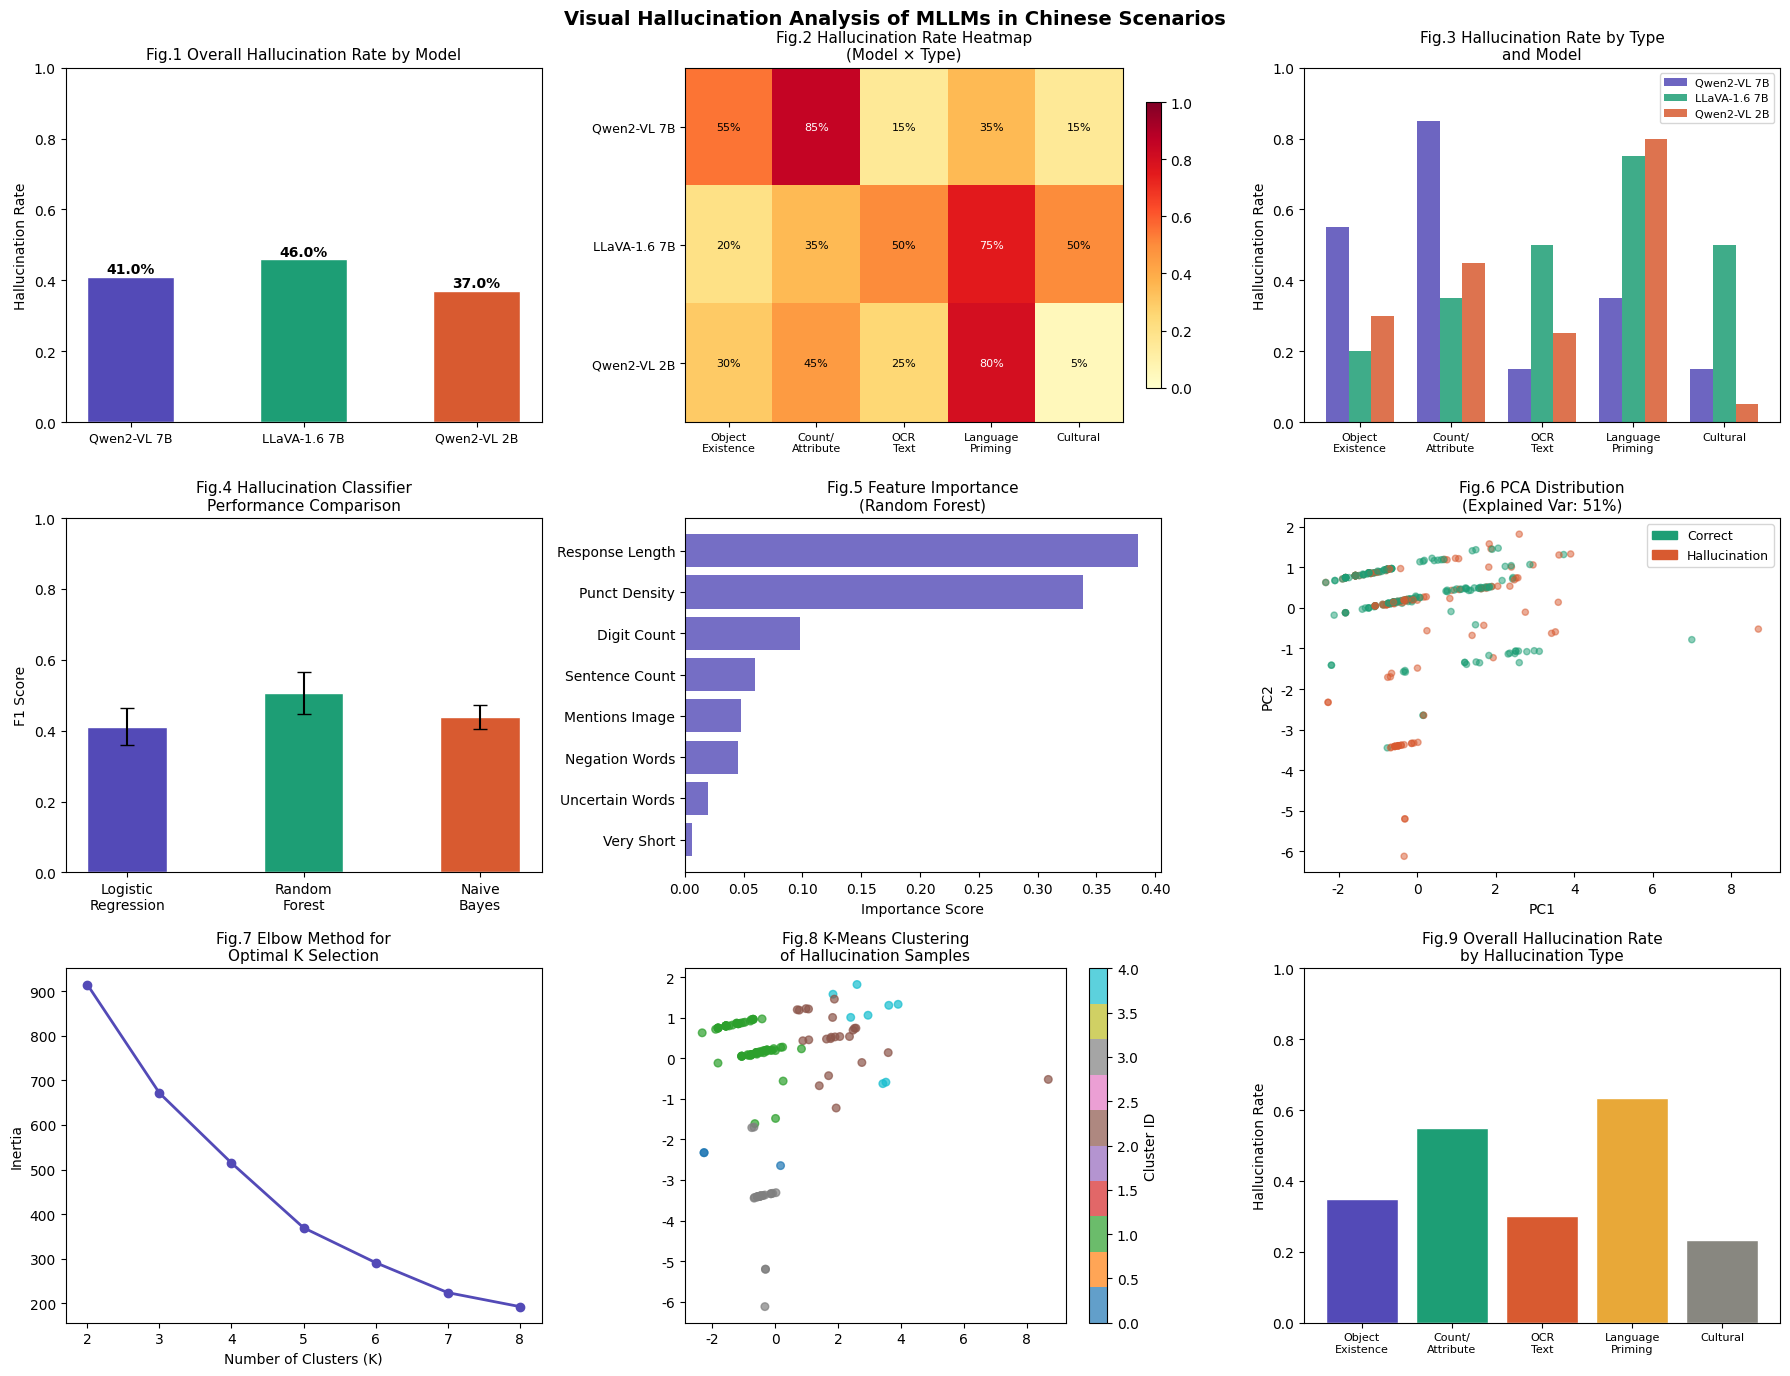


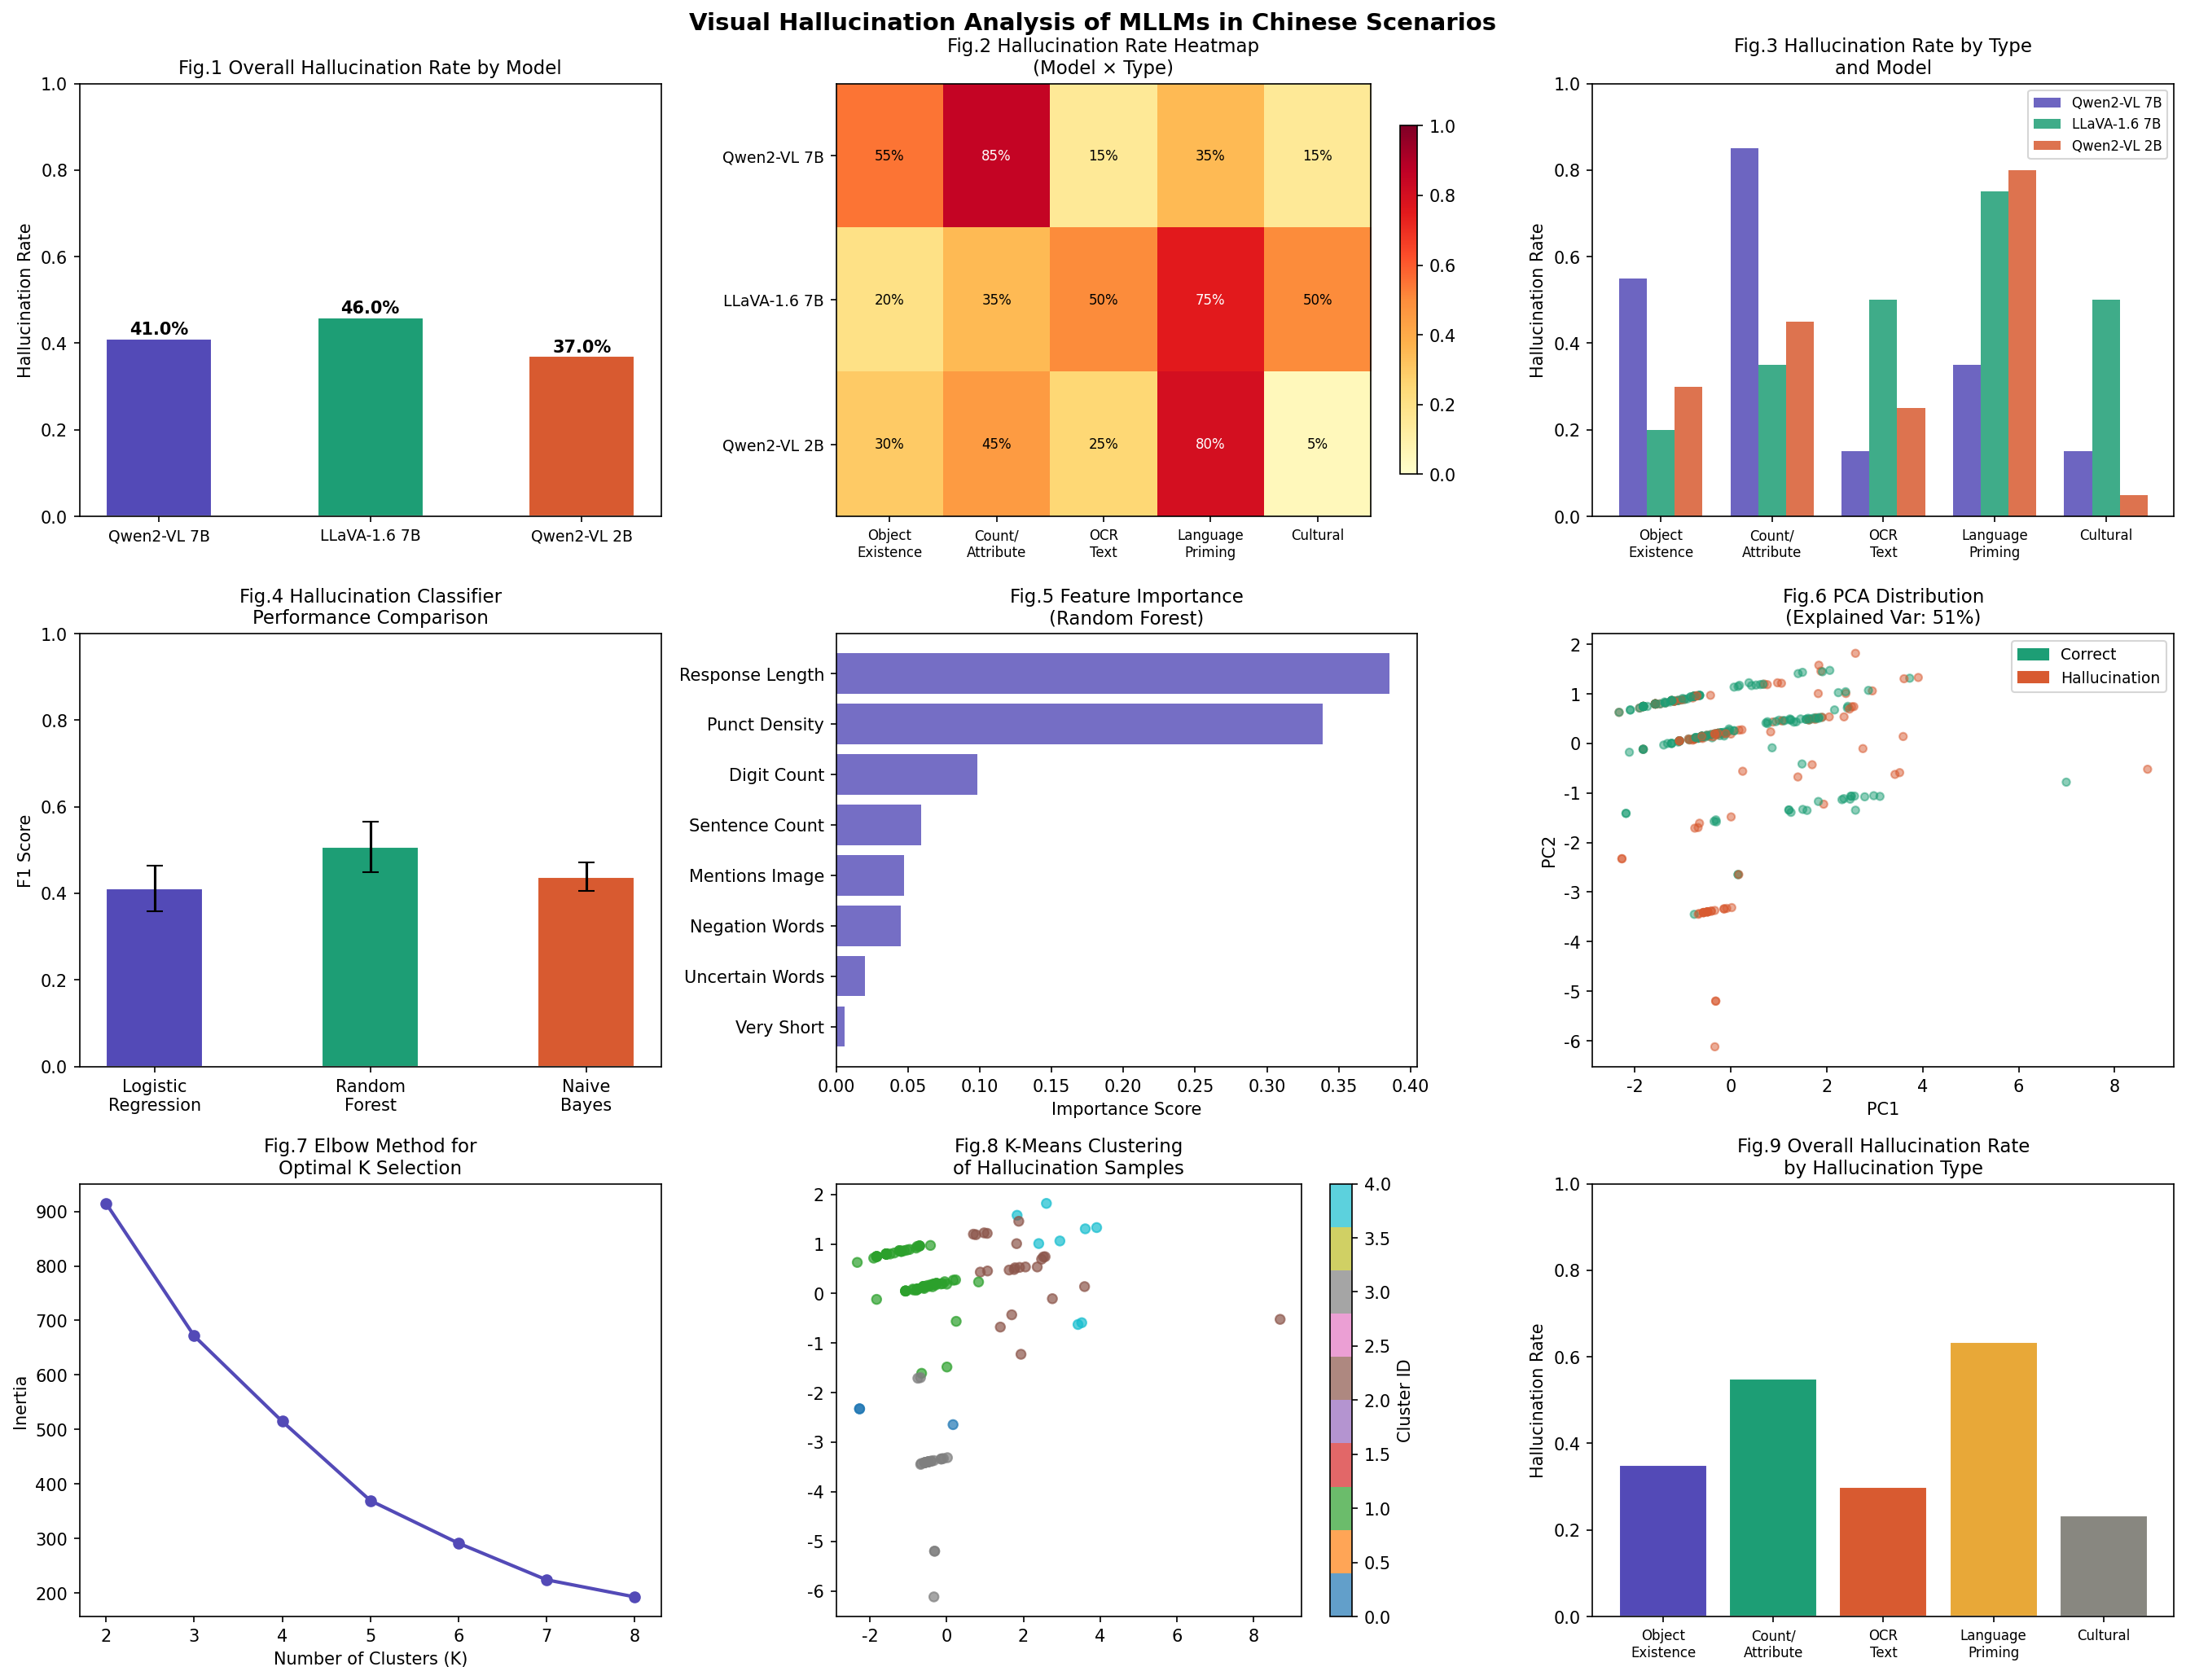

✓ Saved: all_results_en.png


In [19]:
# Cell 5-5 顶部，删掉之前的中文字体配置，换成这个
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# 所有标签改英文
TYPES     = ["object_existence","count_attr","ocr_text",
             "lang_priming","cultural"]
TYPES_EN  = ["Object\nExistence","Count/\nAttribute",
             "OCR\nText","Language\nPriming","Cultural"]
MODELS    = ["qwen","llava","qwen2b"]
MODELS_EN = ["Qwen2-VL 7B","LLaVA-1.6 7B","Qwen2-VL 2B"]

FEATURE_EN = ["Response Length","Uncertain Words","Negation Words",
              "Digit Count","Sentence Count","Mentions Image",
              "Punct Density","Very Short"]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Visual Hallucination Analysis of MLLMs in Chinese Scenarios",
             fontsize=14, fontweight="bold", y=0.98)

# ── 图1：总体幻觉率 ──
ax1 = fig.add_subplot(3, 3, 1)
model_hall = {m: df_zh_all[df_zh_all["model"]==m]["is_hallucination"].mean()
              for m in MODELS}
bars = ax1.bar(MODELS_EN, list(model_hall.values()),
               color=["#534AB7","#1D9E75","#D85A30"],
               width=0.5, edgecolor="white")
for bar, val in zip(bars, model_hall.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.01,
             f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")
ax1.set_ylim(0, 1)
ax1.set_ylabel("Hallucination Rate")
ax1.set_title("Fig.1 Overall Hallucination Rate by Model", fontsize=11)
ax1.tick_params(axis="x", labelsize=9)

# ── 图2：热力图 ──
ax2 = fig.add_subplot(3, 3, 2)
matrix = []
for m in MODELS:
    df_m = df_zh_all[df_zh_all["model"]==m]
    row  = [df_m[df_m["type"]==t]["is_hallucination"].mean() for t in TYPES]
    matrix.append(row)
im = ax2.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax2.set_xticks(range(len(TYPES)))
ax2.set_xticklabels(TYPES_EN, fontsize=8)
ax2.set_yticks(range(len(MODELS)))
ax2.set_yticklabels(MODELS_EN, fontsize=9)
for i in range(len(MODELS)):
    for j in range(len(TYPES)):
        ax2.text(j, i, f"{matrix[i][j]:.0%}",
                 ha="center", va="center", fontsize=8,
                 color="white" if matrix[i][j] > 0.6 else "black")
plt.colorbar(im, ax=ax2, fraction=0.03)
ax2.set_title("Fig.2 Hallucination Rate Heatmap\n(Model × Type)", fontsize=11)

# ── 图3：三模型各类型对比 ──
ax3 = fig.add_subplot(3, 3, 3)
x = range(len(TYPES))
w = 0.25
colors_model = ["#534AB7","#1D9E75","#D85A30"]
for i, (m, men) in enumerate(zip(MODELS, MODELS_EN)):
    df_m  = df_zh_all[df_zh_all["model"]==m]
    rates = [df_m[df_m["type"]==t]["is_hallucination"].mean() for t in TYPES]
    ax3.bar([xi+(i-1)*w for xi in x], rates, w,
            label=men, color=colors_model[i], alpha=0.85)
ax3.set_xticks(list(x))
ax3.set_xticklabels(TYPES_EN, fontsize=8)
ax3.set_ylim(0, 1)
ax3.set_ylabel("Hallucination Rate")
ax3.set_title("Fig.3 Hallucination Rate by Type\nand Model", fontsize=11)
ax3.legend(fontsize=8)

# ── 图4：分类器对比 ──
ax4 = fig.add_subplot(3, 3, 4)
clf_names_en = ["Logistic\nRegression","Random\nForest","Naive\nBayes"]
f1_means = [clf_results[n]["f1"]     for n in clf_results]
f1_stds  = [clf_results[n]["f1_std"] for n in clf_results]
ax4.bar(clf_names_en, f1_means, yerr=f1_stds,
        color=["#534AB7","#1D9E75","#D85A30"],
        capsize=5, width=0.45, edgecolor="white")
ax4.set_ylim(0, 1)
ax4.set_ylabel("F1 Score")
ax4.set_title("Fig.4 Hallucination Classifier\nPerformance Comparison", fontsize=11)

# ── 图5：特征重要性 ──
ax5 = fig.add_subplot(3, 3, 5)
idx = np.argsort(importances)
ax5.barh([FEATURE_EN[i] for i in idx],
         [importances[i] for i in idx],
         color="#534AB7", alpha=0.8)
ax5.set_title("Fig.5 Feature Importance\n(Random Forest)", fontsize=11)
ax5.set_xlabel("Importance Score")

# ── 图6：PCA 散点图 ──
ax6 = fig.add_subplot(3, 3, 6)
colors_point = ["#1D9E75" if yi==0 else "#D85A30" for yi in y]
ax6.scatter(X_2d[:,0], X_2d[:,1], c=colors_point, alpha=0.5, s=20)
from matplotlib.patches import Patch
ax6.legend(handles=[Patch(color="#1D9E75", label="Correct"),
                    Patch(color="#D85A30", label="Hallucination")],
           fontsize=9)
ax6.set_title(f"Fig.6 PCA Distribution\n(Explained Var: {sum(var):.0%})",
              fontsize=11)
ax6.set_xlabel("PC1")
ax6.set_ylabel("PC2")

# ── 图7：肘部法则 ──
ax7 = fig.add_subplot(3, 3, 7)
ax7.plot(range(2,9), inertias, "o-", color="#534AB7", linewidth=2)
ax7.set_xlabel("Number of Clusters (K)")
ax7.set_ylabel("Inertia")
ax7.set_title("Fig.7 Elbow Method for\nOptimal K Selection", fontsize=11)

# ── 图8：K-Means 聚类 ──
ax8 = fig.add_subplot(3, 3, 8)
X_hall_2d = X_2d[hall_mask]
sc = ax8.scatter(X_hall_2d[:,0], X_hall_2d[:,1],
                 c=hall_clusters, cmap="tab10", alpha=0.7, s=30)
plt.colorbar(sc, ax=ax8, label="Cluster ID")
ax8.set_title("Fig.8 K-Means Clustering\nof Hallucination Samples", fontsize=11)

# ── 图9：各类型总体幻觉率 ──
ax9 = fig.add_subplot(3, 3, 9)
type_hall = {t: df_zh_all[df_zh_all["type"]==t]["is_hallucination"].mean()
             for t in TYPES}
ax9.bar(TYPES_EN, list(type_hall.values()),
        color=["#534AB7","#1D9E75","#D85A30","#E8A838","#888780"],
        edgecolor="white")
ax9.set_ylim(0, 1)
ax9.set_ylabel("Hallucination Rate")
ax9.set_title("Fig.9 Overall Hallucination Rate\nby Hallucination Type", fontsize=11)
ax9.tick_params(axis="x", labelsize=8)

plt.tight_layout()
save_path = "/kaggle/working/all_results_en.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

# 下载
import base64
from IPython.display import HTML, display
with open(save_path, "rb") as f:
    data = base64.b64encode(f.read()).decode()
html = f'<a download="all_results_en.png" href="data:image/png;base64,{data}">Download Figure</a>'
display(HTML(html))
print("✓ Saved: all_results_en.png")


In [ ]:
import base64
from IPython.display import HTML, display

with open("/kaggle/working/all_results.png", "rb") as f:
    data = base64.b64encode(f.read()).decode()
html = f'<a download="all_results.png" href="data:image/png;base64,{data}">点击下载图表</a>'
display(HTML(html))

In [ ]:
# ── Cell 5-6：打印关键结论数据（报告直接引用）────────────────────
print("\n" + "="*55)
print("关键实验结论（报告第五章直接引用）")
print("="*55)

print("\n【各模型总体幻觉率】")
for m, mzh in zip(MODELS, MODELS_ZH):
    rate = df_zh_all[df_zh_all["model"]==m]["is_hallucination"].mean()
    print(f"  {mzh}: {rate:.1%}")

print("\n【各幻觉类型幻觉率（三模型平均）】")
for t, tzh in zip(TYPES, TYPES_ZH):
    rate = df_zh_all[df_zh_all["type"]==t]["is_hallucination"].mean()
    print(f"  {tzh}: {rate:.1%}")



print("\n【分类器性能】")
for name, res in clf_results.items():
    print(f"  {name}: F1={res['f1']:.3f}  Acc={res['acc']:.3f}")

print("\n【最重要的幻觉预测特征（Top 3）】")
top3_idx = np.argsort(importances)[::-1][:3]
for rank, i in enumerate(top3_idx, 1):
    print(f"  {rank}. {FEATURE_ZH[i]}: {importances[i]:.3f}")